In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("patient_data.csv")
print(df.shape)        # rows, columns
df.head()

(101766, 25)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,gender,race,...,max_glu_serum,diabetesMed,change,insulin,metformin,glipizide,glyburide,pioglitazone,rosiglitazone,readmitted
0,1,41,0,1,0,0,0,1,Female,Caucasian,...,NaN,No,No,No,No,No,No,No,No,NO
1,3,59,0,18,0,0,0,9,Female,Caucasian,...,NaN,Yes,Ch,Up,No,No,No,No,No,>30
2,2,11,5,13,2,0,1,6,Female,AfricanAmerican,...,NaN,Yes,No,No,No,Steady,No,No,No,NO
3,2,44,1,16,0,0,0,7,Male,Caucasian,...,NaN,Yes,Ch,Up,No,No,No,No,No,NO
4,1,51,0,8,0,0,0,5,Male,Caucasian,...,NaN,Yes,Ch,Steady,No,Steady,No,No,No,NO


In [49]:
df.describe()  

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,admission_type_id,discharge_disposition_id,admission_source_id
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,2.024006,3.715642,5.754437
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,1.445403,5.280166,4.064081
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,1.000000,1.000000,1.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,1.000000,1.000000,7.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,3.000000,4.000000,7.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,8.000000,28.000000,25.000000


In [29]:
df.isnull().sum().sort_values(ascending=False)

max_glu_serum               96420
A1Cresult                   84748
race                         2273
time_in_hospital                0
age                             0
rosiglitazone                   0
pioglitazone                    0
glyburide                       0
glipizide                       0
metformin                       0
insulin                         0
change                          0
diabetesMed                     0
admission_source_id             0
num_lab_procedures              0
discharge_disposition_id        0
admission_type_id               0
gender                          0
number_diagnoses                0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
readmitted                      0
dtype: int64

In [67]:
df['readmitted'].value_counts().reset_index()

,readmitted,count
0,NO,54864
1,>30,35545
2,<30,11357


In [71]:
df['readmitted'] = df['readmitted'].replace({
        '<30': 1,
        '>30': 0,
        'NO': 0
    })

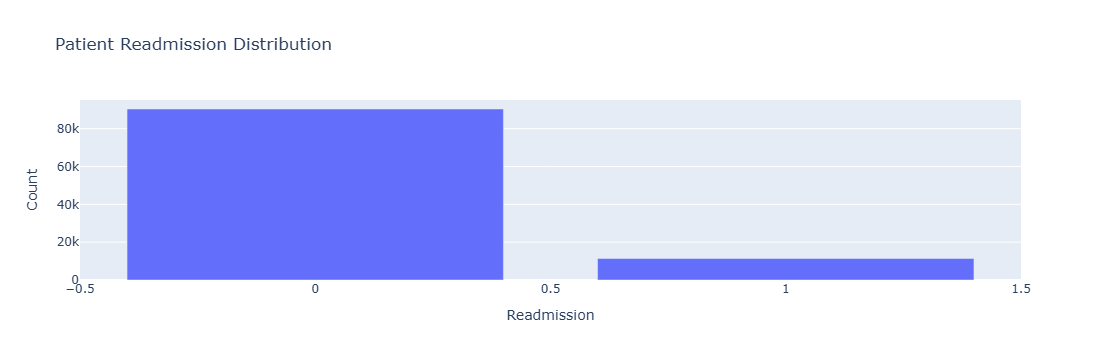

In [73]:
fig = px.bar(df["readmitted"].value_counts().reset_index(),
             x="readmitted",
             y="count",
             title="Patient Readmission Distribution")
fig.update_layout(xaxis_title="Readmission",
                  yaxis_title="Count")
fig.show()

In [31]:
df["age"].value_counts().reset_index().sort_values(by="age")

,age,count
9,[0-10),161
8,[10-20),691
7,[20-30),1657
5,[30-40),3775
4,[40-50),9685
2,[50-60),17256
1,[60-70),22483
0,[70-80),26068
3,[80-90),17197
6,[90-100),2793


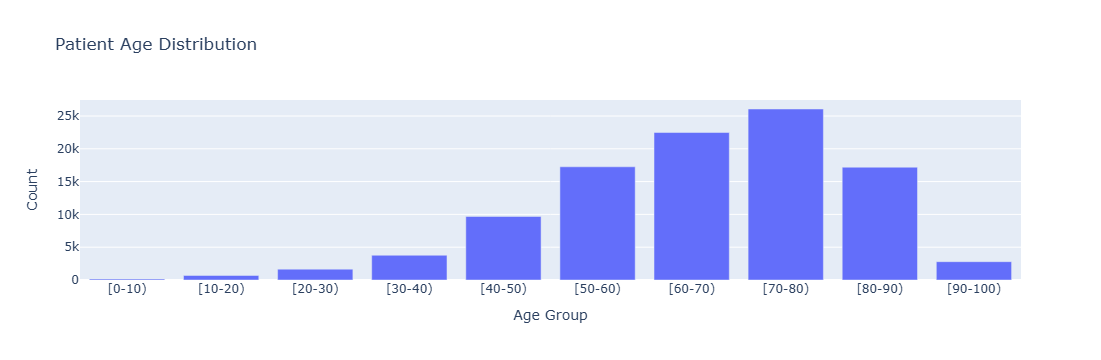

In [33]:

fig = px.bar(df["age"].value_counts().reset_index().sort_values(by="age"), x="age", y="count", title="Patient Age Distribution")
fig.update_layout(xaxis_title="Age Group",
                  yaxis_title="Count")
fig.show()

In [37]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

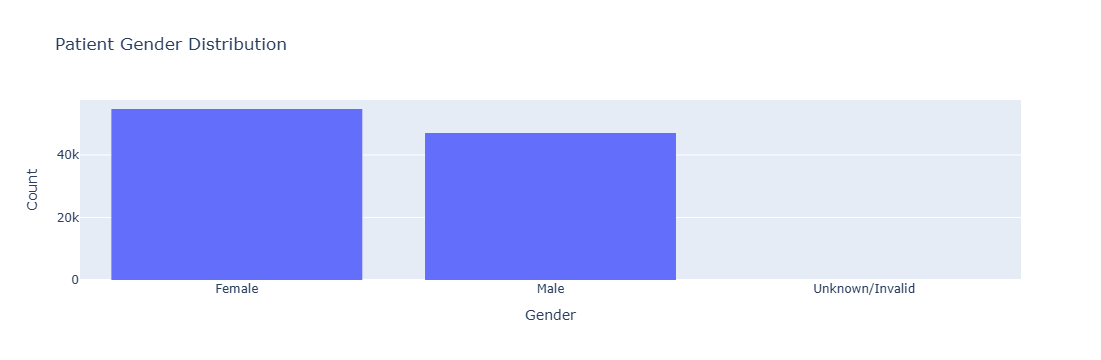

In [39]:
fig = px.histogram(df, x="gender", title="Patient Gender Distribution")
fig.update_layout(xaxis_title="Gender",
                  yaxis_title="Count")
fig.show()

In [41]:
df['admission_type_id'].value_counts()

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

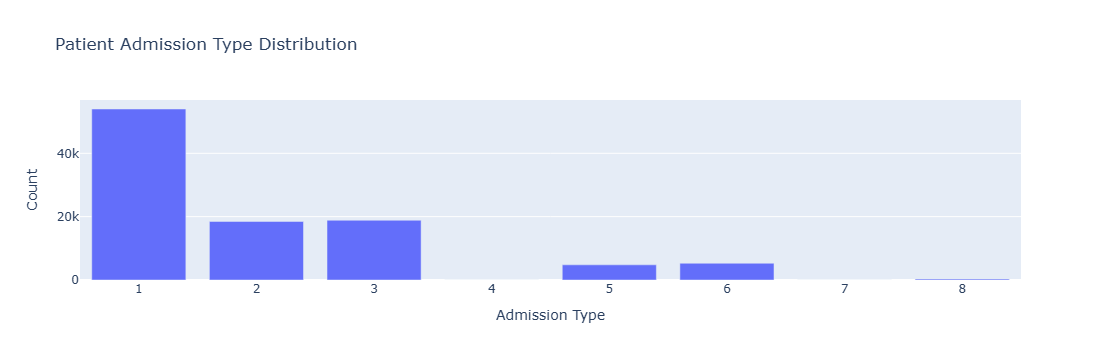

In [23]:
fig = px.bar(df["admission_type_id"].value_counts().reset_index(),
             x="admission_type_id",
             y="count",
             title="Patient Admission Type Distribution")

fig.update_layout(xaxis_title="Admission Type",
                  yaxis_title="Count")

fig.show()

In [43]:
df['readmitted'].value_counts().reset_index()

,readmitted,count
0,NO,54864
1,>30,35545
2,<30,11357


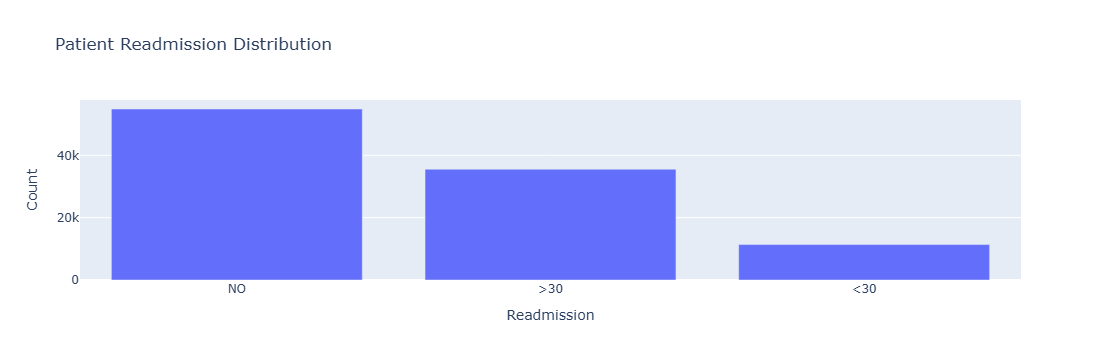

In [45]:
fig = px.bar(df["readmitted"].value_counts().reset_index(),
             x="readmitted",
             y="count",
             title="Patient Readmission Distribution")
fig.update_layout(xaxis_title="Readmission",
                  yaxis_title="Count")
fig.show()

In [57]:
df['max_glu_serum'] = df['max_glu_serum'].fillna('NotMeasured')
df["max_glu_serum"].value_counts().reset_index().sort_values(by="max_glu_serum")

,max_glu_serum,count
2,>200,1485
3,>300,1264
1,Norm,2597
0,NotMeasured,96420


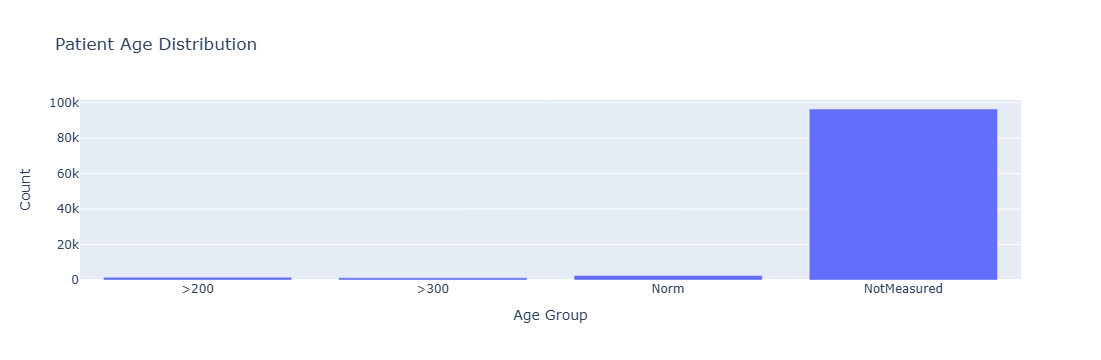

In [55]:

fig = px.bar(df["max_glu_serum"].value_counts().reset_index().sort_values(by="max_glu_serum"), x="max_glu_serum", y="count", title="max_glu_serum Distribution")
fig.update_layout(xaxis_title="max_glu_serum",
                  yaxis_title="Count")
fig.show()

In [59]:
df['A1Cresult'] = df['A1Cresult'].fillna('NotMeasured')
df["A1Cresult"].value_counts().reset_index().sort_values(by="A1Cresult")

,A1Cresult,count
3,>7,3812
1,>8,8216
2,Norm,4990
0,NotMeasured,84748


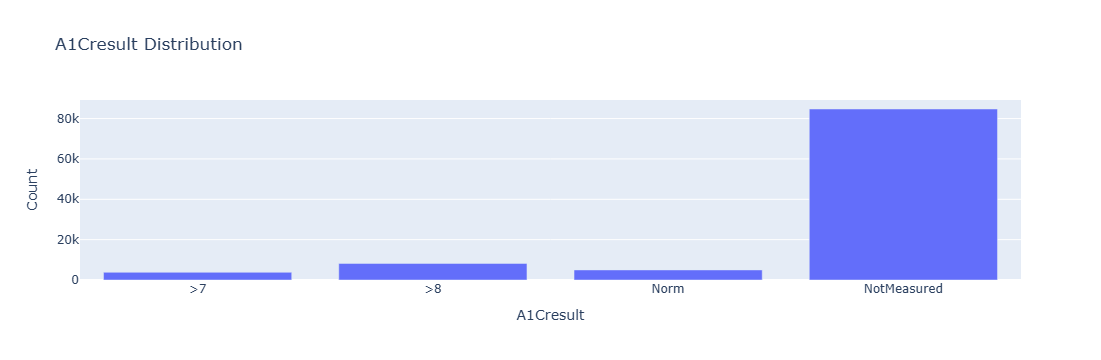

In [61]:
fig = px.bar(df["A1Cresult"].value_counts().reset_index().sort_values(by="A1Cresult"), x="A1Cresult", y="count", title="A1Cresult Distribution")
fig.update_layout(xaxis_title="A1Cresult",
                  yaxis_title="Count")
fig.show()

In [63]:
df['race'] = df['race'].fillna('Unknown')
df["race"].value_counts().reset_index().sort_values(by="race")

,race,count
1,AfricanAmerican,19210
5,Asian,641
0,Caucasian,76099
3,Hispanic,2037
4,Other,1506
2,Unknown,2273


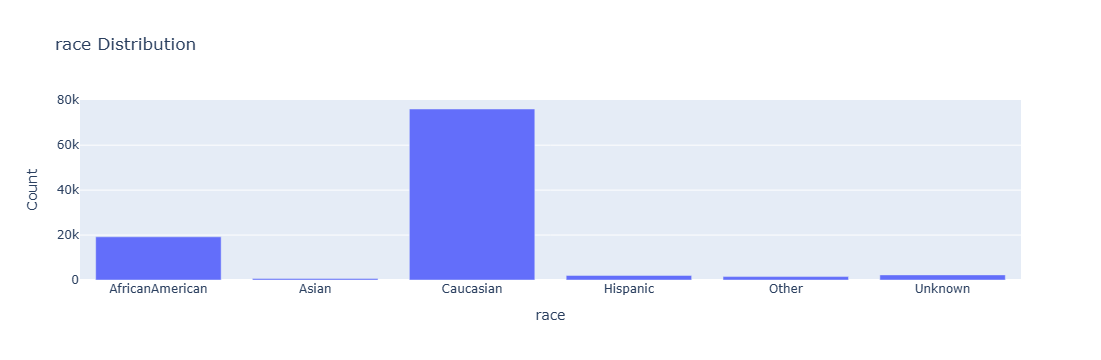

In [65]:
fig = px.bar(df["race"].value_counts().reset_index().sort_values(by="race"), x="race", y="count", title="race Distribution")
fig.update_layout(xaxis_title="race",
                  yaxis_title="Count")
fig.show()

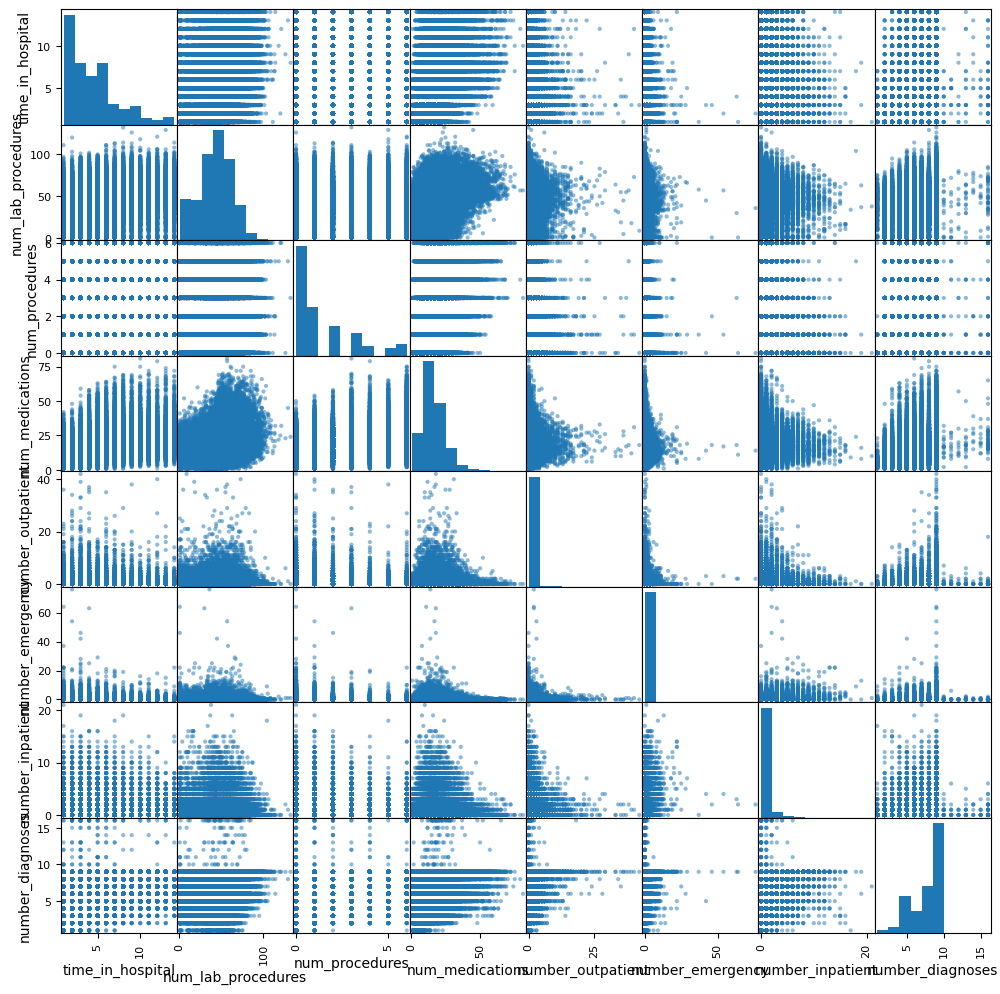

In [97]:
features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

scatter_matrix(df[features], figsize=(12, 12))

plt.show()

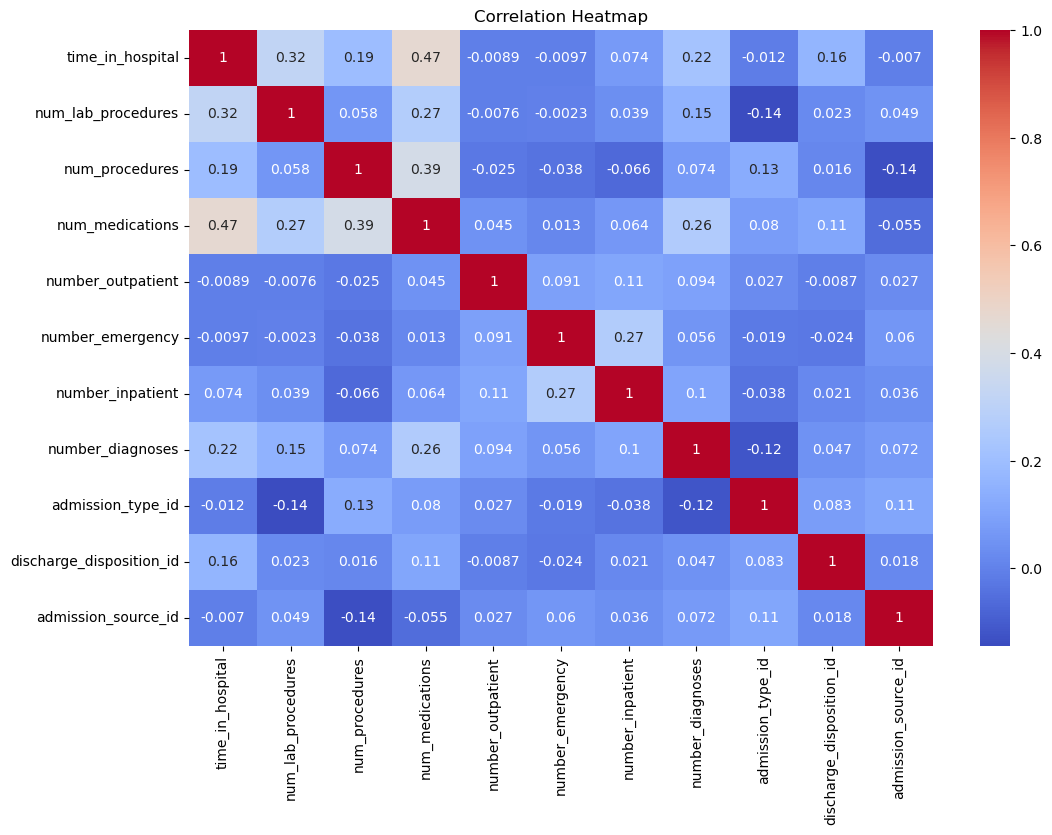

In [95]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))  
sns.heatmap(corr, annot=True, cmap='coolwarm', )
plt.title("Correlation Heatmap")
plt.show()